In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
dm = pd.read_csv("matches.csv")
dd = pd.read_csv("deliveries.csv")
dm.head()


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [2]:
dm.shape

(1095, 20)

In [3]:
dm.columns

Index(['id', 'season', 'city', 'date', 'match_type', 'player_of_match',
       'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner',
       'result', 'result_margin', 'target_runs', 'target_overs', 'super_over',
       'method', 'umpire1', 'umpire2'],
      dtype='object')

In [4]:
dm.isnull().sum()

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

In [5]:
dm = dm.drop(columns = "method")

In [6]:
dm.isnull().sum()


id                  0
season              0
city               51
date                0
match_type          0
player_of_match     5
venue               0
team1               0
team2               0
toss_winner         0
toss_decision       0
winner              5
result              0
result_margin      19
target_runs         3
target_overs        3
super_over          0
umpire1             0
umpire2             0
dtype: int64

In [7]:
dm["city"] = dm["city"].fillna("Unknown")

In [8]:
dm.isnull().sum()

id                  0
season              0
city                0
date                0
match_type          0
player_of_match     5
venue               0
team1               0
team2               0
toss_winner         0
toss_decision       0
winner              5
result              0
result_margin      19
target_runs         3
target_overs        3
super_over          0
umpire1             0
umpire2             0
dtype: int64

In [9]:
dm["player_of_match"] = dm["player_of_match"].fillna("Not Known")
dm["winner"] = dm["winner"].fillna("No Result")
dm["result_margin"] = dm["result_margin"].fillna(0)
dm["target_overs"] = dm["target_overs"].fillna(0)
dm["target_runs"] = dm["target_runs"].fillna(0)
dm.isnull().sum()

id                 0
season             0
city               0
date               0
match_type         0
player_of_match    0
venue              0
team1              0
team2              0
toss_winner        0
toss_decision      0
winner             0
result             0
result_margin      0
target_runs        0
target_overs       0
super_over         0
umpire1            0
umpire2            0
dtype: int64

In [10]:
dd.isnull().sum()

match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed    247970
dismissal_kind      247970
fielder             251566
dtype: int64

In [11]:
dd.shape

(260920, 17)

In [12]:
dd.columns


Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs',
       'total_runs', 'extras_type', 'is_wicket', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='object')

In [13]:
dm.columns

Index(['id', 'season', 'city', 'date', 'match_type', 'player_of_match',
       'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner',
       'result', 'result_margin', 'target_runs', 'target_overs', 'super_over',
       'umpire1', 'umpire2'],
      dtype='object')

In [14]:
df = pd.merge(dm,dd,right_on = "match_id",left_on = "id",how = "left")

In [15]:
df.columns 

Index(['id', 'season', 'city', 'date', 'match_type', 'player_of_match',
       'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner',
       'result', 'result_margin', 'target_runs', 'target_overs', 'super_over',
       'umpire1', 'umpire2', 'match_id', 'inning', 'batting_team',
       'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker',
       'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket',
       'player_dismissed', 'dismissal_kind', 'fielder'],
      dtype='object')

In [16]:
df.isnull().sum()

id                       0
season                   0
city                     0
date                     0
match_type               0
player_of_match          0
venue                    0
team1                    0
team2                    0
toss_winner              0
toss_decision            0
winner                   0
result                   0
result_margin            0
target_runs              0
target_overs             0
super_over               0
umpire1                  0
umpire2                  0
match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed    247970
dismissal_kind      247970
fielder             251566
dtype: int64

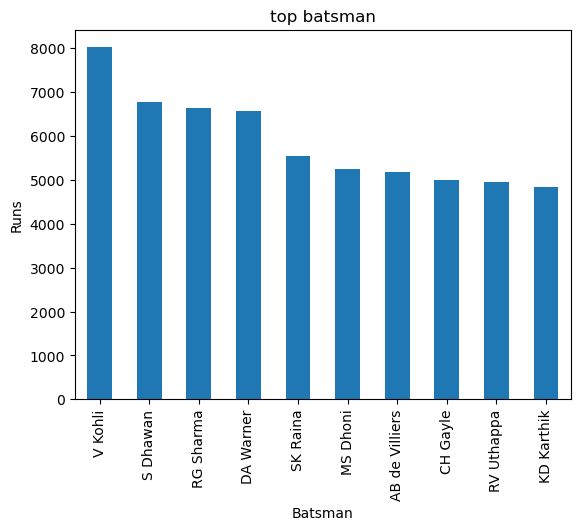

In [17]:
top_batters = df.groupby("batter")["batsman_runs"].sum().sort_values(ascending = False).head(10)
top_batters.plot(kind = "bar")
plt.title("top batsman")
plt.xlabel("Batsman")
plt.ylabel("Runs")
plt.show()

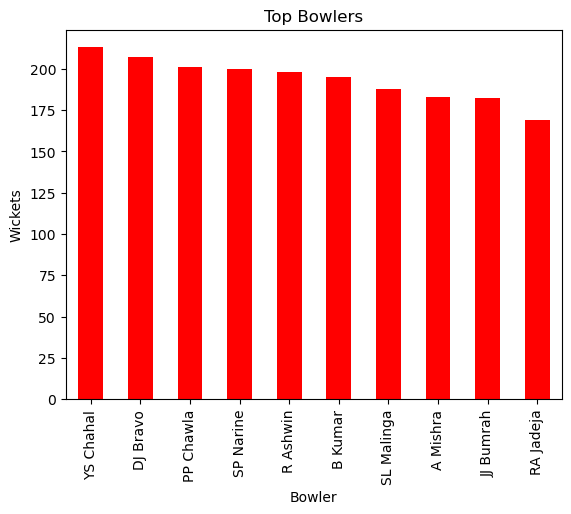

In [18]:
top_bowlers = df.groupby("bowler")["is_wicket"].sum().sort_values(ascending = False).head(10)
top_bowlers.plot(kind = "bar",color = "red")
plt.xlabel("Bowler")
plt.ylabel("Wickets")
plt.title("Top Bowlers")
plt.show()

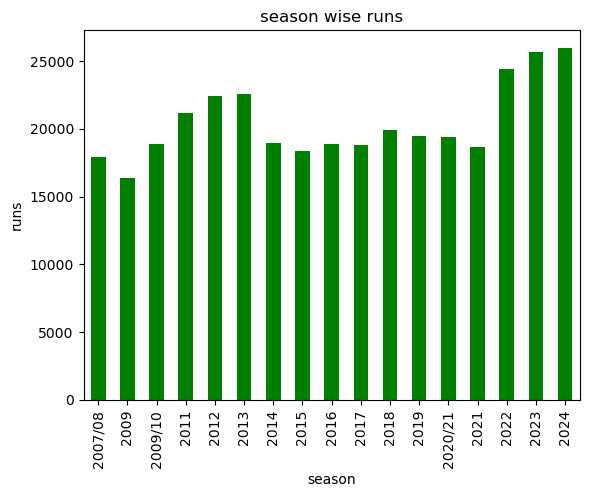

In [19]:
season = df.groupby("season")["total_runs"].sum().plot(kind = "bar",color = "green")
plt.title("season wise runs")
plt.xlabel("season")
plt.ylabel("runs")
plt.show()

In [20]:
matches = df.drop_duplicates('match_id')
toss_win_pct = (matches['toss_winner'] == matches['winner']).mean() * 100
print(f"Toss winner wins: {toss_win_pct}")

Toss winner wins: 50.593607305936075


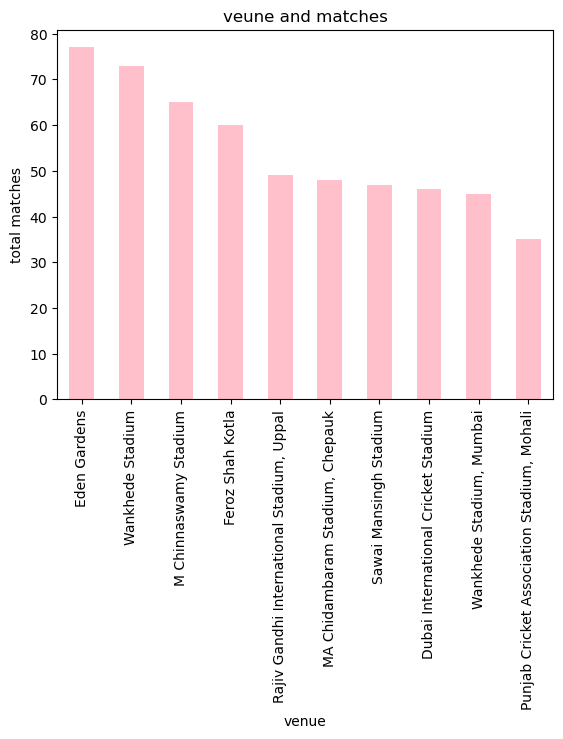

In [21]:
top_venues = df.groupby("venue")["match_id"].nunique().sort_values(ascending = False).head(10).plot(kind = "bar",color = "pink")
plt.title("veune and matches")
plt.xlabel("venue")
plt.ylabel("total matches")
plt.show()

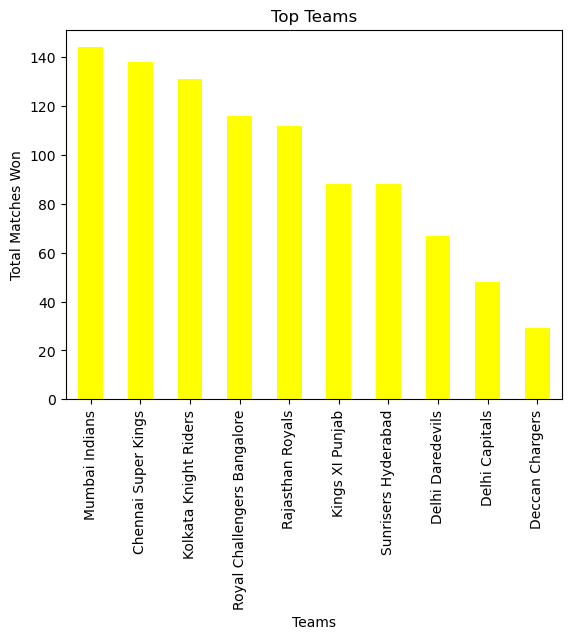

In [22]:
top_teams = matches[matches["winner"] != "No Result"]["winner"].value_counts().head(10)
top_teams.plot(kind = "bar",color = "yellow")
plt.title("Top Teams")
plt.xlabel("Teams")
plt.ylabel("Total Matches Won")
plt.show()

In [24]:
df.to_csv(r"C:\Users\EKANKSH\Downloads\finalipldataset.csv",index = False)